# 03. K-Nearest Neighbors (KNN)

Este notebook implementa e avalia o modelo **K-Nearest Neighbors (KNN)** aplicado ao dataset **Breast Cancer Wisconsin Diagnostic (WDBC)**.

Diferente do Naive Bayes, que é probabilístico, o KNN é um algoritmo baseado em instâncias e distância geométrica. Ele classifica uma nova amostra com base na classe majoritária dos seus $k$ vizinhos mais próximos no espaço de *features*.

**Pontos de atenção para este modelo:**
- **Sensibilidade à Escala:** Por calcular distâncias (ex: Euclidiana), o KNN é extremamente dependente de dados escalonados. O uso do nosso `pipeline.py` (que aplica padronização) é crucial para o seu funcionamento.
- **Probabilidades Discretas**: A probabilidade gerada pelo KNN não é contínua. Como o nosso modelo otimizado selecionou $k=3$, as probabilidades serão sempre degraus de aproximadamente 33,3% (0.0, 0.33, 0.66, 1.0), representando a proporção de vizinhos (0/3, 1/3, 2/3 ou 3/3) de cada classe.

O foco principal da análise, alinhado à nossa hipótese, continua sendo o **Recall da classe Maligno** (minimização de Falsos Negativos).

---
## 1. Importações e Configuração do Ambiente

In [1]:
# 1. Importando bibliotecas e pipeline centralizado
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from pipeline import run_pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    recall_score, precision_score, accuracy_score, f1_score
)

from sklearn.model_selection import cross_val_score

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


---
## 2.1 Justificativa e Otimização do Hiperparâmetro K

Para evitar a escolha arbitrária do parâmetro padrão da biblioteca, realizamos uma busca pelo melhor número de vizinhos ($k$). 
Testaremos valores ímpares de 1 a 19, avaliando qual $k$ maximiza o **Recall da classe Maligno** (nossa métrica alvo), evitando overfitting (que geralmente ocorre com $k=1$).

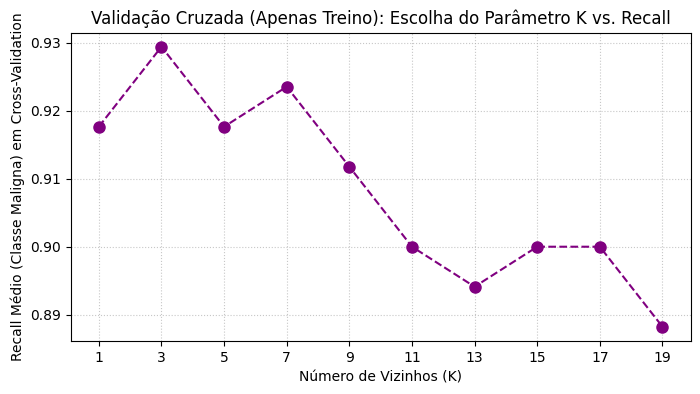

In [2]:
# 2. Carregando os dados pré-processados e padronizados
X_train, X_test, y_train, y_test = run_pipeline()

# Lista para armazenar os resultados
k_values = range(1, 20, 2)
recalls_cv = []

# Loop para avaliar o modelo APENAS no conjunto de TREINO usando Validação Cruzada (5 folds)
for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    # cross_val_score divide o X_train internamente em 5 partes, treina em 4 e avalia em 1.
    scores = cross_val_score(knn_temp, X_train, y_train, cv=5, scoring='recall')
    recalls_cv.append(scores.mean()) # Guarda a média dos 5 testes internos

# Plotando a Curva de Validação Cruzada
plt.figure(figsize=(8, 4))
plt.plot(k_values, recalls_cv, marker='o', linestyle='dashed', color='purple', markersize=8)
plt.title('Validação Cruzada (Apenas Treino): Escolha do Parâmetro K vs. Recall')
plt.xlabel('Número de Vizinhos (K)')
plt.ylabel('Recall Médio (Classe Maligna) em Cross-Validation')
plt.xticks(k_values)
plt.grid(True, linestyle=':', alpha=0.7)

# Salvando gráfico para o artigo!
plt.savefig("outputs/otimizacao_k_knn.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 2.2 Treinamento do Modelo Final

Com base na Curva de Validação gerada acima, selecionamos o valor de $k$ que estabiliza o Recall em seu ponto máximo sem forçar o modelo a olhar para um número excessivo de vizinhos (o que adicionaria ruído) ou vizinhos insuficientes (risco de memorizar o ruído - *overfitting*).

*(Nota: O valor de k abaixo foi escolhido observando o pico no gráfico gerado na etapa anterior).*

In [3]:
# 3. Treinando o K-Nearest Neighbors
melhor_k = 3 

print(f"Treinando o modelo final com k={melhor_k} fundamentado pela Curva de Validação Cruzada.")
knn = KNeighborsClassifier(n_neighbors=melhor_k)
knn.fit(X_train, y_train)

Treinando o modelo final com k=3 fundamentado pela Curva de Validação Cruzada.


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


---
## 3. Previsões e Métricas de Avaliação

In [4]:
# 4.1 Gerando previsões e probabilidades
y_pred_knn  = knn.predict(X_test)
# Pegando a probabilidade de pertencer à classe 1 (Maligno)
y_proba_knn = knn.predict_proba(X_test)[:, 1]

In [5]:
# 4.2 Relatório de classificação
print("=" * 50)
print("K-NEAREST NEIGHBORS (k=3)")
print("=" * 50)
print(classification_report(y_test, y_pred_knn, target_names=["Benigno", "Maligno"]))
print(f"Recall (Maligno): {recall_score(y_test, y_pred_knn):.4f}")

K-NEAREST NEIGHBORS (k=3)
              precision    recall  f1-score   support

     Benigno       0.92      0.99      0.95        72
     Maligno       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114

Recall (Maligno): 0.8571


---
## 4. Matriz de Confusão

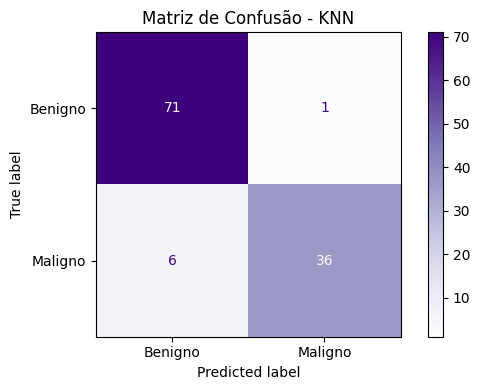

In [6]:
# 5. Gerando e salvando a matriz de confusão
cm = confusion_matrix(y_test, y_pred_knn)

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay(cm, display_labels=["Benigno", "Maligno"]).plot(ax=ax, cmap="Purples")
ax.set_title("Matriz de Confusão - KNN")

plt.tight_layout()
plt.savefig("outputs/matriz_knn.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

---
## 5. Análise de Threshold — KNN

Como nossa questão de pesquisa foca em minimizar Falsos Negativos, precisamos avaliar como o modelo se comporta se reduzirmos o limite de decisão (threshold). 

Devido à natureza do KNN, a análise de threshold tem um comportamento peculiar. Com $k=3$, as probabilidades de um tumor ser classificado como maligno são estritamente limitadas às frações dos vizinhos: $0/3$, $1/3$, $2/3$ ou $3/3$.

In [7]:
# 6.1 Distribuição das probabilidades preditas (Notem os valores discretos)
print("Distribuição das probabilidades (classe Maligno) geradas pelo KNN:")
print(pd.Series(y_proba_knn).value_counts().sort_index())

Distribuição das probabilidades (classe Maligno) geradas pelo KNN:
0.000000    69
0.333333     8
0.666667     6
1.000000    31
Name: count, dtype: int64


In [8]:
# 6.2 Tabela de métricas por threshold
print("=== ANÁLISE DE THRESHOLD — KNN (k=3) ===")
print(f"{'Threshold':<12} {'Recall':>8} {'Precisão':>10} {'Acurácia':>10} {'F1':>8} {'Falsos Neg.':>13}")
print("-" * 65)

# Limiares ajustados para os "degraus" matemáticos do KNN com k=3 (0.33 e 0.66)
thresholds = [0.70, 0.50, 0.30]
resultados_threshold = []

for t in thresholds:
    y_pred_t = (y_proba_knn >= t).astype(int)
    rec  = recall_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    acc  = accuracy_score(y_test, y_pred_t)
    f1   = f1_score(y_test, y_pred_t)
    fn   = confusion_matrix(y_test, y_pred_t)[1][0]
    print(f"{t:<12.2f} {rec:>8.4f} {prec:>10.4f} {acc:>10.4f} {f1:>8.4f} {fn:>13}")
    resultados_threshold.append((t, rec, prec, acc, f1, fn))

=== ANÁLISE DE THRESHOLD — KNN (k=3) ===
Threshold      Recall   Precisão   Acurácia       F1   Falsos Neg.
-----------------------------------------------------------------
0.70           0.7381     1.0000     0.9035   0.8493            11
0.50           0.8571     0.9730     0.9386   0.9114             6
0.30           0.9762     0.9111     0.9561   0.9425             1


Diferentemente do Naive Bayes, a análise de threshold no KNN apresenta uma escadaria de decisão muito clara baseada nos vizinhos.Para classificar um tumor como Maligno pelo padrão (probabilidade $\ge 0.5$), é necessário que a maioria, ou seja, pelo menos 2 dos 3 vizinhos ($66,6\%$) sejam da classe maligna. Ao ajustarmos o threshold para $0.30$, informamos ao modelo que se apenas 1 dos 3 vizinhos ($33,3\%$) apontar malignidade, isso já é suspeito o suficiente para disparar o alarme clínico, reduzindo os falsos negativos.Isso embasa a discussão de que, no contexto oncológico, conhecer a natureza discreta das probabilidades do modelo baseado em instâncias permite uma manipulação exata e consciente na busca pela eliminação de Falsos Negativos.